# 05_VRR12_消融实验

目标：验证主异常窗口（`Readings ≈ 12115~12135`）是否依赖 `VRR12` 这一列而存在。

核心问题：
1. 去掉 `VRR12` 之后，末端异常窗口是否仍然存在？
2. 去掉 `VRR12` 之后，top10 最异常样本是否仍然集中在该窗口附近？
3. 这一步如何帮助判断 `VRR12` 是“主驱动变量”还是“背景切换变量”？

## 思路说明

我们做两次异常检测：

- **Baseline（全特征）**：保留 `VRR12`
- **Ablation（消融）**：去掉 `VRR12`

然后比较：
- 全局 anomaly score 曲线
- `12050~12267` 局部曲线
- top10 最异常样本
- 异常窗口 `12115~12135` 是否仍然明显

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

## 1. 读取并清洗数据

In [16]:
df = pd.read_csv("../data/PWR Abnormality Dataset.csv")

# 清洗 Flow2
df["Flow2"] = df["Flow2"].astype(str).str.strip().str.replace(",", ".", regex=False)
df["Flow2"] = pd.to_numeric(df["Flow2"], errors="coerce")

print(df.shape)
df.head()

(12267, 17)


,Readings,Temperature,Pressure,Flow1,Flow2,VRR12,VRR22,VRR23,VRR33,VRS01,VRS03,VRS21,VRS31,VRS02,VRI01,VRI02,VRI03
0,1,248.852987,9.689813,4462.130014,13302.92650,19.060938,0.059119,0.050589,0.111864,0.033951,0.047812,0.232627,0.253775,0.400726,1.763223,0.003031,0.004995
1,2,269.315740,1.279532,4480.252595,13784.45225,19.062128,0.059089,0.048788,0.111340,0.034060,0.052611,0.233342,0.315067,0.128517,1.769272,0.003164,0.004999
2,3,94.320644,6.280686,4325.270376,12899.98773,19.061641,0.058145,0.048552,0.111118,0.033859,0.053999,0.233387,0.380191,0.321816,1.768585,0.003321,0.004996
3,4,271.019823,0.669886,4481.761795,13733.00610,19.062453,0.058236,0.049514,0.112658,0.034049,0.050767,0.233850,0.329846,0.132092,1.772432,0.003061,0.004998
4,5,207.876262,6.806043,4425.839490,13500.22222,19.061101,0.058378,0.049809,0.111252,0.033996,0.052669,0.233619,0.390729,0.247973,1.772356,0.003060,0.004994


## 2. 定义主异常窗口

In [17]:
window_start, window_end = 12115, 12135
target_start, target_end = 12050, 12267

## 3. Baseline：保留 VRR12

In [8]:
df_full = df.drop(columns=["Readings"]).copy()

scaler_full = StandardScaler()
X_full = scaler_full.fit_transform(df_full)

model_full = IsolationForest(contamination=0.05, random_state=42)
pred_full = model_full.fit_predict(X_full)
score_full = model_full.decision_function(X_full)

result_full = df.copy()
result_full["anomaly_label_full"] = pred_full
result_full["anomaly_score_full"] = score_full

print(result_full["anomaly_label_full"].value_counts())

anomaly_label_full
 1    11653
-1      614
Name: count, dtype: int64


## 4. Ablation：去掉 VRR12

In [18]:
df_no_vrr12 = df.drop(columns=["Readings", "VRR12"]).copy()

scaler_no = StandardScaler()
X_no = scaler_no.fit_transform(df_no_vrr12)

model_no = IsolationForest(contamination=0.05, random_state=42)
pred_no = model_no.fit_predict(X_no)
score_no = model_no.decision_function(X_no)

result_no = df.copy()
result_no["anomaly_label_no_vrr12"] = pred_no
result_no["anomaly_score_no_vrr12"] = score_no

print(result_no["anomaly_label_no_vrr12"].value_counts())

anomaly_label_no_vrr12
 1    11653
-1      614
Name: count, dtype: int64


## 5. Top10 对比

In [10]:
top10_full = result_full.sort_values(by="anomaly_score_full").head(10)
top10_no = result_no.sort_values(by="anomaly_score_no_vrr12").head(10)

print("=== 带 VRR12 的 top10 ===")
display(top10_full[["Readings", "Temperature", "Pressure", "Flow1", "Flow2",
                    "anomaly_label_full", "anomaly_score_full"]])

print("=== 去掉 VRR12 的 top10 ===")
display(top10_no[["Readings", "Temperature", "Pressure", "Flow1", "Flow2",
                  "anomaly_label_no_vrr12", "anomaly_score_no_vrr12"]])

=== 带 VRR12 的 top10 ===


,Readings,Temperature,Pressure,Flow1,Flow2,anomaly_label_full,anomaly_score_full
12127,12128,287.8287,16.57636,4461.264172,14388.58200,-1,-0.104763
12124,12125,288.0672,16.58000,4484.036774,13972.37300,-1,-0.100793
12129,12130,287.5891,16.58719,4427.619761,13927.95706,-1,-0.097707
12118,12119,287.9721,16.47419,4480.147273,14956.03029,-1,-0.095733
12119,12120,287.9612,16.57160,4425.837560,14831.58653,-1,-0.094140
12121,12122,287.8750,16.57655,4409.037954,14942.36383,-1,-0.092506
12128,12129,287.6377,16.57587,4354.601835,13553.30673,-1,-0.092421
12123,12124,287.9897,16.57410,4369.390259,14016.13886,-1,-0.091411
12131,12132,287.6651,16.00017,4412.651254,13402.11830,-1,-0.091046
12116,12117,288.0049,16.57498,4322.022756,14935.33727,-1,-0.090921


=== 去掉 VRR12 的 top10 ===


,Readings,Temperature,Pressure,Flow1,Flow2,anomaly_label_no_vrr12,anomaly_score_no_vrr12
12124,12125,288.067200,16.58000,4484.036774,13972.37300,-1,-0.060695
12127,12128,287.828700,16.57636,4461.264172,14388.58200,-1,-0.060145
5335,5336,72.022897,0.17066,4305.522655,13850.90180,-1,-0.057502
12121,12122,287.875000,16.57655,4409.037954,14942.36383,-1,-0.056335
12118,12119,287.972100,16.47419,4480.147273,14956.03029,-1,-0.054243
12125,12126,288.073400,16.57695,4468.350153,13992.93964,-1,-0.053047
12132,12133,288.101900,15.84118,4470.677644,14076.71190,-1,-0.051845
12133,12134,288.121700,15.93663,4320.069414,13768.99966,-1,-0.048892
12123,12124,287.989700,16.57410,4369.390259,14016.13886,-1,-0.044116
12116,12117,288.004900,16.57498,4322.022756,14935.33727,-1,-0.043231


## 6. 全局 anomaly score 对比

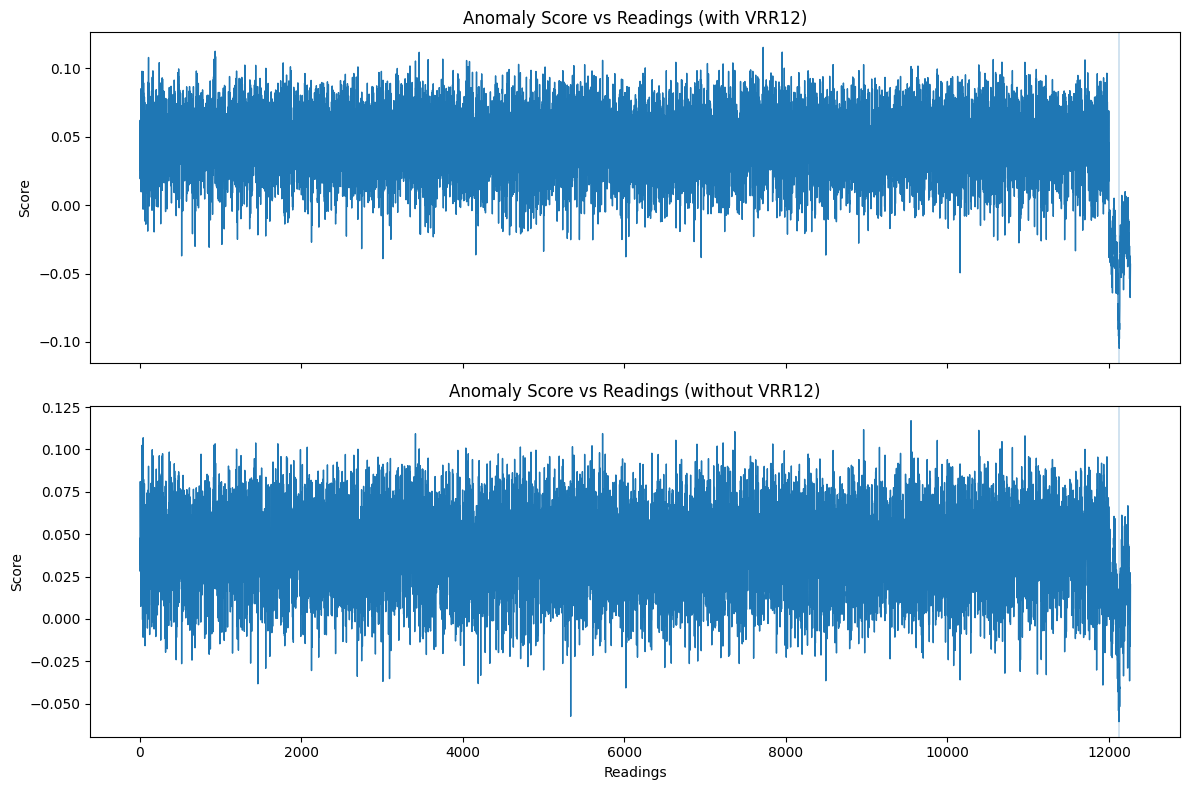

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(result_full["Readings"], result_full["anomaly_score_full"], linewidth=1)
axes[0].axvspan(window_start, window_end, alpha=0.2)
axes[0].set_ylabel("Score")
axes[0].set_title("Anomaly Score vs Readings (with VRR12)")

axes[1].plot(result_no["Readings"], result_no["anomaly_score_no_vrr12"], linewidth=1)
axes[1].axvspan(window_start, window_end, alpha=0.2)
axes[1].set_ylabel("Score")
axes[1].set_xlabel("Readings")
axes[1].set_title("Anomaly Score vs Readings (without VRR12)")

plt.tight_layout()
plt.show()

## 7. 局部窗口对比（12050~12267）

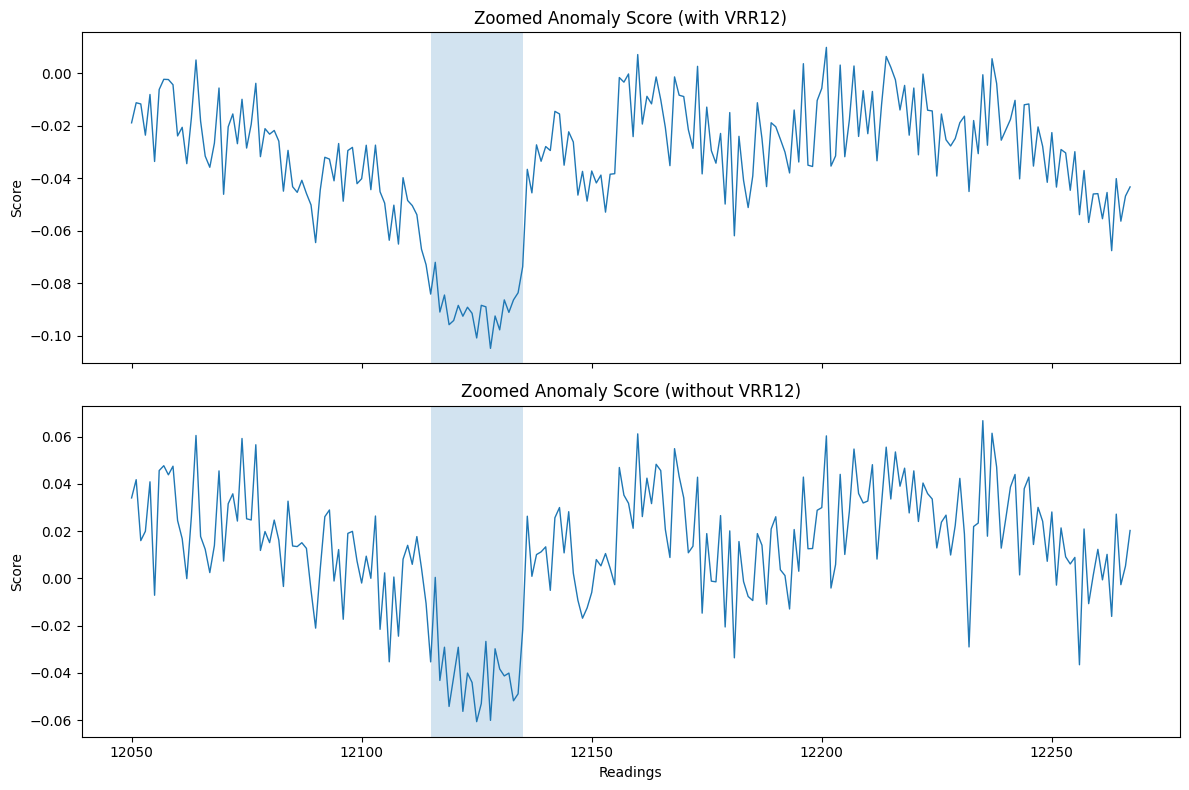

In [12]:
zoom_full = result_full[(result_full["Readings"] >= target_start) & (result_full["Readings"] <= target_end)].copy()
zoom_no = result_no[(result_no["Readings"] >= target_start) & (result_no["Readings"] <= target_end)].copy()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(zoom_full["Readings"], zoom_full["anomaly_score_full"], linewidth=1)
axes[0].axvspan(window_start, window_end, alpha=0.2)
axes[0].set_ylabel("Score")
axes[0].set_title("Zoomed Anomaly Score (with VRR12)")

axes[1].plot(zoom_no["Readings"], zoom_no["anomaly_score_no_vrr12"], linewidth=1)
axes[1].axvspan(window_start, window_end, alpha=0.2)
axes[1].set_ylabel("Score")
axes[1].set_xlabel("Readings")
axes[1].set_title("Zoomed Anomaly Score (without VRR12)")

plt.tight_layout()
plt.show()

## 8. 统计：top10 有多少个点落在主异常窗口里？

In [13]:
def count_in_window(df_top, reading_col="Readings", start=12115, end=12135):
    return ((df_top[reading_col] >= start) & (df_top[reading_col] <= end)).sum()

count_full = count_in_window(top10_full, "Readings", window_start, window_end)
count_no = count_in_window(top10_no, "Readings", window_start, window_end)

summary_df = pd.DataFrame({
    "setting": ["with_VRR12", "without_VRR12"],
    "top10_points_in_window": [count_full, count_no]
})

display(summary_df)

,setting,top10_points_in_window
0,with_VRR12,10
1,without_VRR12,9


## 9. 补充发现：去掉 VRR12 后出现单点极端异常 5336

在去掉 `VRR12` 后，模型除了继续识别主异常窗口 `12115~12135` 之外，还在 top10 最异常样本中暴露出一个新的孤立点异常：`Readings = 5336`。

这说明：
- `VRR12` 并非主异常窗口的唯一驱动变量；
- 去掉 `VRR12` 后，模型仍能稳定识别连续窗口异常；
- 同时还会突出另一类异常模式，即低温低压主导的单点极端异常。

因此，当前可以初步认为数据中至少同时存在两类异常模式：
1. 连续窗口异常：以 `12115~12135` 为代表；
2. 孤立点异常：以 `5336` 为代表。

Readings = 5336 的样本信息：


,Readings,Temperature,Pressure,Flow1,Flow2,anomaly_label_no_vrr12,anomaly_score_no_vrr12
5335,5336,72.022897,0.17066,4305.522655,13850.9018,-1,-0.057502


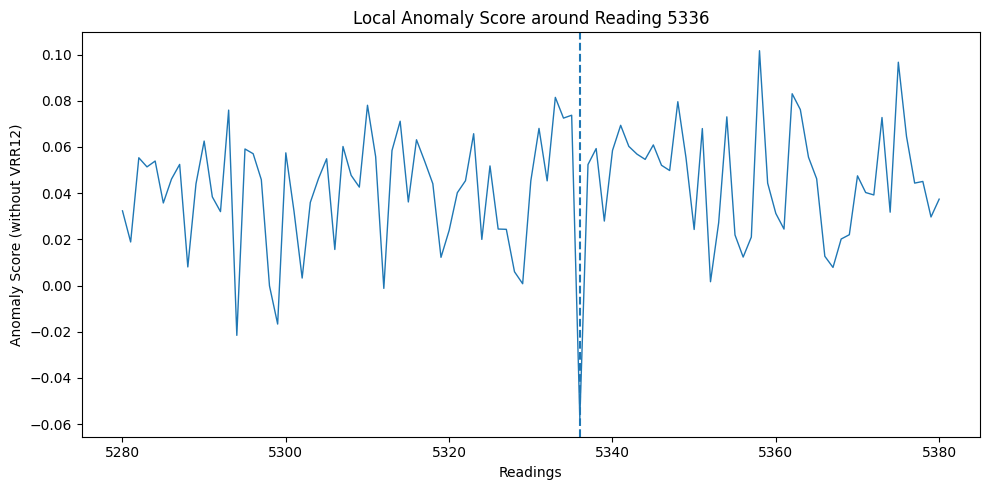

In [22]:
point_5336 = result_no[result_no["Readings"] == 5336]

print("Readings = 5336 的样本信息：")
display(point_5336[[
    "Readings",
    "Temperature",
    "Pressure",
    "Flow1",
    "Flow2",
    "anomaly_label_no_vrr12",
    "anomaly_score_no_vrr12"
]])
zoom_5336 = result_no[
    (result_no["Readings"] >= 5280) &
    (result_no["Readings"] <= 5380)
].copy()

plt.figure(figsize=(10, 5))
plt.plot(zoom_5336["Readings"], zoom_5336["anomaly_score_no_vrr12"], linewidth=1)
plt.axvline(5336, linestyle="--")
plt.xlabel("Readings")
plt.ylabel("Anomaly Score (without VRR12)")
plt.title("Local Anomaly Score around Reading 5336")

plt.tight_layout()
plt.show()

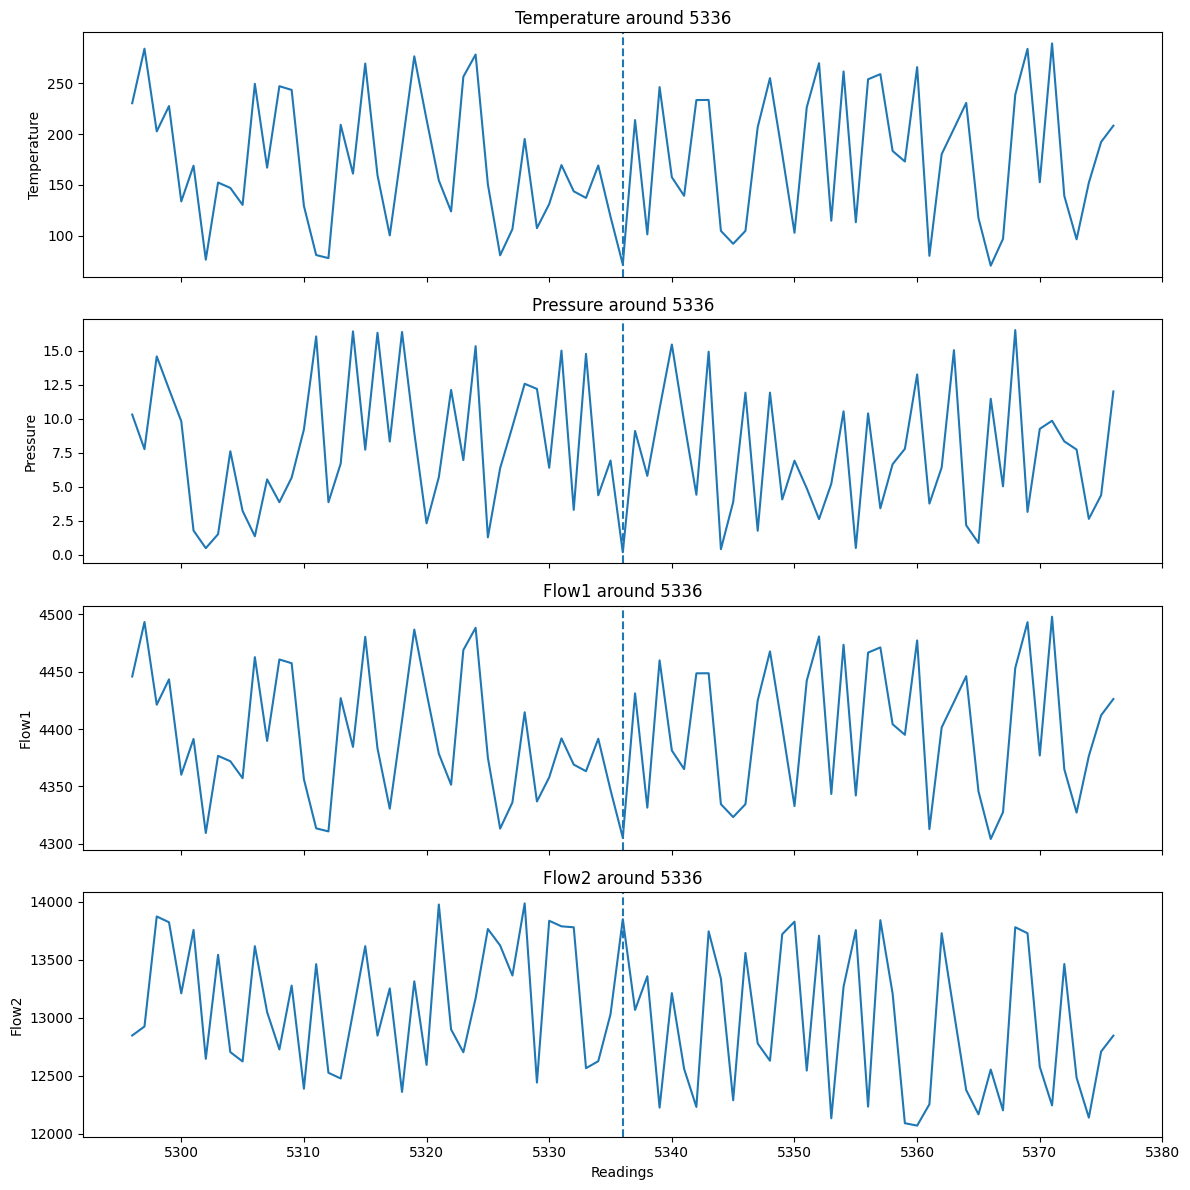

In [23]:
target_reading = 5336
local_df = result_no[(result_no["Readings"] >= target_reading - 40) & (result_no["Readings"] <= target_reading + 40)].copy()
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

axes[0].plot(local_df["Readings"], local_df["Temperature"])
axes[0].axvline(target_reading, linestyle="--")
axes[0].set_ylabel("Temperature")
axes[0].set_title("Temperature around 5336")

axes[1].plot(local_df["Readings"], local_df["Pressure"])
axes[1].axvline(target_reading, linestyle="--")
axes[1].set_ylabel("Pressure")
axes[1].set_title("Pressure around 5336")

axes[2].plot(local_df["Readings"], local_df["Flow1"])
axes[2].axvline(target_reading, linestyle="--")
axes[2].set_ylabel("Flow1")
axes[2].set_title("Flow1 around 5336")

axes[3].plot(local_df["Readings"], local_df["Flow2"])
axes[3].axvline(target_reading, linestyle="--")
axes[3].set_ylabel("Flow2")
axes[3].set_xlabel("Readings")
axes[3].set_title("Flow2 around 5336")

plt.tight_layout()
plt.show()

## 10. 解释



- 如果去掉 `VRR12` 后，`12115~12135` 低谷仍然存在，且 top10 仍然大部分落在该窗口：
  - 说明主异常窗口是**稳健存在**的，并非由 `VRR12` 单列“拉出来”。
  - `VRR12` 更像一个**背景状态切换变量 / 可疑表示变量**。
    -

- 如果去掉 `VRR12` 后，该窗口显著减弱或消失：
  - 说明 `VRR12` 对原始异常检测结果影响很大。
  - 后续需要把 `VRR12` 当作**特殊变量**单独处理。

## 阶段性结论

1. 数据中同时存在两类异常模式：
   - 连续窗口异常：以 `12115~12135` 为代表，表现为高温高压平台内的连续异常区段；
   - 孤立点异常：以 `5336` 为代表，表现为低温低压主导的单点极端异常。

2. `VRR12` 在 `12001` 附近发生显著量级切换，表现出背景状态变化或表示方式变化的可疑特征。

3. 去除 `VRR12` 后，`12115~12135` 主异常窗口仍然存在，且 top10 中 9 个样本仍落在该窗口内，说明主异常窗口并非由 `VRR12` 单独驱动，而是由温度、压力、Flow2 等多变量共同支撑的稳健异常区段。

4. 因此，当前将 `VRR12` 定义为需要单独审查的可疑背景特征变量，而不将其直接等同于主异常窗口本身。